# 3.3. Classification (Predicting Popularity Category)

In [18]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    learning_curve,
)
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)
from sklearn import set_config
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 1. Data preparation

In [19]:
original_df = pd.read_csv('tracks2026.csv')
df = original_df.copy()
df

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


Drop NaN values and track_id. NaN values can be drop, as discussed in EDA. At the same time, the outlier in 'loudness' column (observation 1289) is dropped, as the row also contains NaN values.

In [20]:
df = df.dropna()
df = df.drop(columns = ["track_id"])
df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


Encode explicit-column. This is just replacing Boolean values with 0/1, so this can be done before pipeline.

In [21]:
map_cat = {False: 0, True: 1}
df[['explicit']] = df[['explicit']].replace(map_cat)
df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,44.0,203337,0,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,83.0,208786,0,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,49.0,262373,0,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,41.0,283706,0,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,25.0,266133,0,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,52.0,223236,0,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,0.0,162009,0,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,58.0,120000,0,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


 New target variable. This could be seen as a data leak, but as median is global and robust statistic, we can use the median of the whole dataset.

In [22]:
median_popularity = df["popularity"].median()
df['popularity_binary'] = df["popularity"].apply(lambda x: 0 if x <= median_popularity else 1)
df = df.drop(columns=["popularity"])
# X and y
y = df['popularity_binary']
X = df.drop(columns=["popularity_binary"])
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

Follow the similar principles and decisions as in the data preparation and EDA notebooks.
First plot the data as histograms, not 0/1 values.

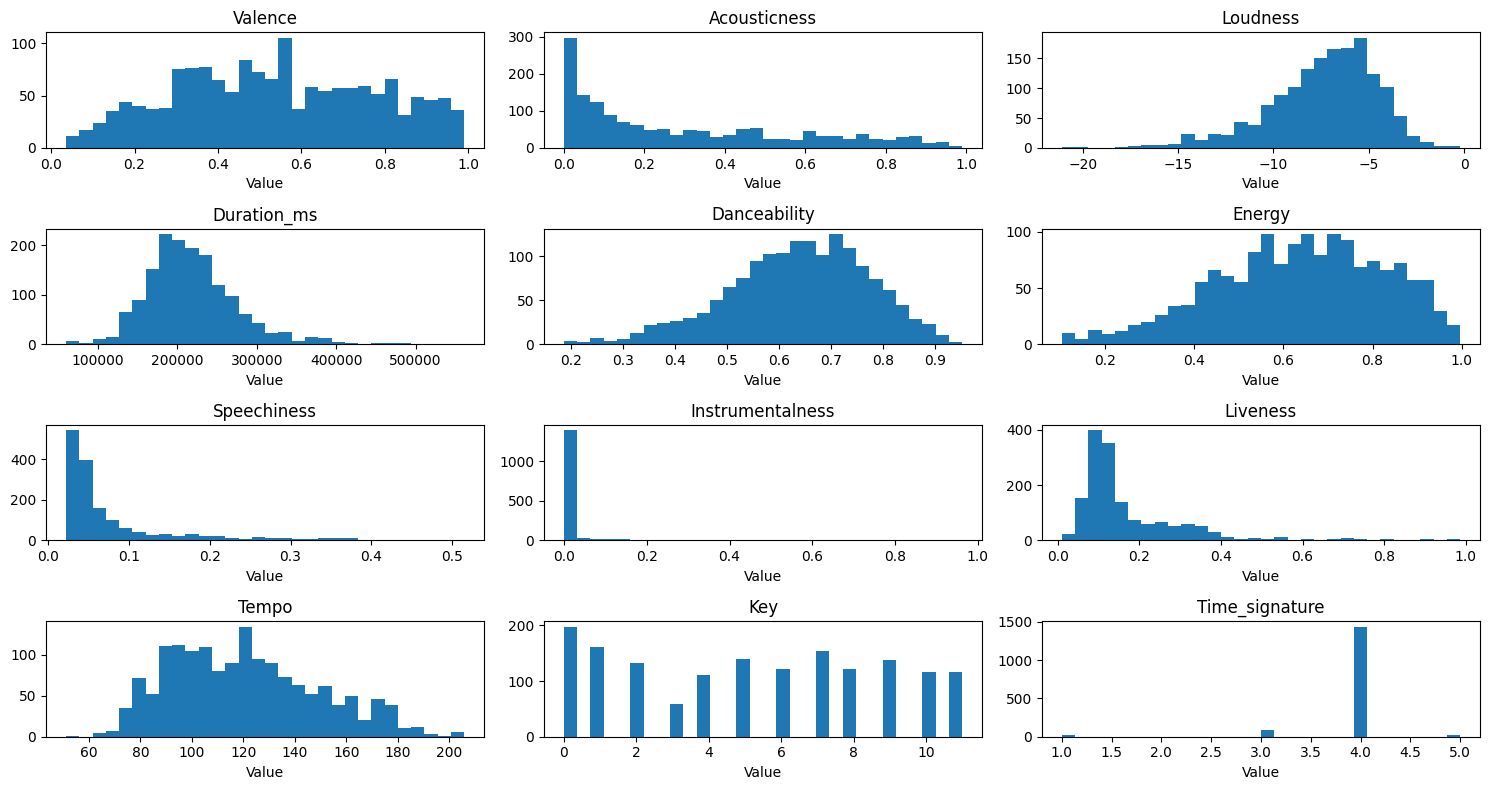

In [23]:
fig, axes = plt.subplots(4, 3, figsize=(15, 8))
axes[0, 0].hist(X_train['valence'], bins=30)
axes[0, 0].set_title('Valence')
axes[0, 0].set_xlabel('Value')

axes[0, 1].hist(X_train['acousticness'], bins=30)
axes[0, 1].set_title('Acousticness')
axes[0, 1].set_xlabel('Value')

axes[0, 2].hist(X_train['loudness'], bins=30)
axes[0, 2].set_title('Loudness')
axes[0, 2].set_xlabel('Value')

axes[1, 0].hist(X_train['duration_ms'], bins=30)
axes[1, 0].set_title('Duration_ms')
axes[1, 0].set_xlabel('Value')

axes[1, 1].hist(X_train['danceability'], bins=30)
axes[1, 1].set_title('Danceability')
axes[1, 1].set_xlabel('Value')

axes[1, 2].hist(X_train['energy'], bins=30)
axes[1, 2].set_title('Energy')
axes[1, 2].set_xlabel('Value')

axes[2, 0].hist(X_train['speechiness'], bins=30)
axes[2, 0].set_title('Speechiness')
axes[2, 0].set_xlabel('Value')

axes[2, 1].hist(X_train['instrumentalness'], bins=30)
axes[2, 1].set_title('Instrumentalness')
axes[2, 1].set_xlabel('Value')

axes[2, 2].hist(X_train['liveness'], bins=30)
axes[2, 2].set_title('Liveness')
axes[2, 2].set_xlabel('Value')

axes[3, 0].hist(X_train['tempo'], bins=30)
axes[3, 0].set_title('Tempo')
axes[3, 0].set_xlabel('Value')

axes[3, 1].hist(X_train['key'], bins=30)
axes[3, 1].set_title('Key')
axes[3, 1].set_xlabel('Value')

axes[3, 2].hist(X_train['time_signature'], bins=30)
axes[3, 2].set_title('Time_signature')
axes[3, 2].set_xlabel('Value')
plt.tight_layout()
plt.show()

Plot the data in boxplot, not 0/1 values.

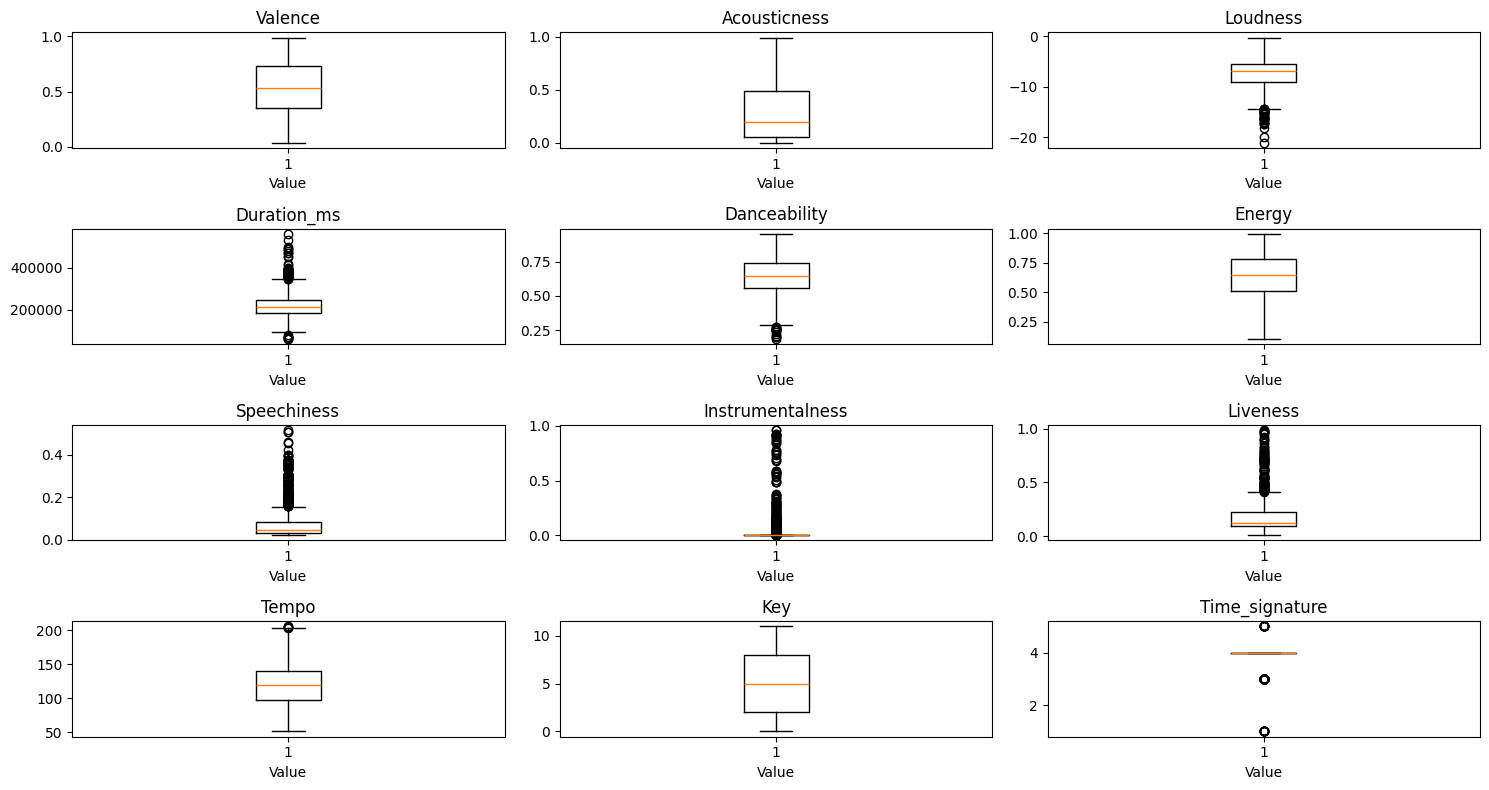

In [24]:
fig, axes = plt.subplots(4, 3, figsize=(15, 8))
axes[0, 0].boxplot(X_train['valence'])
axes[0, 0].set_title('Valence')
axes[0, 0].set_xlabel('Value')

axes[0, 1].boxplot(X_train['acousticness'])
axes[0, 1].set_title('Acousticness')
axes[0, 1].set_xlabel('Value')

axes[0, 2].boxplot(X_train['loudness'])
axes[0, 2].set_title('Loudness')
axes[0, 2].set_xlabel('Value')

axes[1, 0].boxplot(X_train['duration_ms'])
axes[1, 0].set_title('Duration_ms')
axes[1, 0].set_xlabel('Value')

axes[1, 1].boxplot(X_train['danceability'])
axes[1, 1].set_title('Danceability')
axes[1, 1].set_xlabel('Value')

axes[1, 2].boxplot(X_train['energy'])
axes[1, 2].set_title('Energy')
axes[1, 2].set_xlabel('Value')

axes[2, 0].boxplot(X_train['speechiness'])
axes[2, 0].set_title('Speechiness')
axes[2, 0].set_xlabel('Value')

axes[2, 1].boxplot(X_train['instrumentalness'])
axes[2, 1].set_title('Instrumentalness')
axes[2, 1].set_xlabel('Value')

axes[2, 2].boxplot(X_train['liveness'])
axes[2, 2].set_title('Liveness')
axes[2, 2].set_xlabel('Value')

axes[3, 0].boxplot(X_train['tempo'])
axes[3, 0].set_title('Tempo')
axes[3, 0].set_xlabel('Value')

axes[3, 1].boxplot(X_train['key'])
axes[3, 1].set_title('Key')
axes[3, 1].set_xlabel('Value')

axes[3, 2].boxplot(X_train['time_signature'])
axes[3, 2].set_title('Time_signature')
axes[3, 2].set_xlabel('Value')
plt.tight_layout()
plt.show()

Based on boxplots and histograms, do the following preprosessing:

In [25]:
# Numerical features, no outliers
no_outlier_cols = ['valence', 'acousticness']
# Negative values, outliers
outlier_cols_neg = ['loudness']
# Positive values, outliers
outlier_cols_pos = ['duration_ms', 'danceability', 'energy', 'speechiness', 'liveness', 'tempo']
# Need to be just scaled, as they are discrete.
key_timesignature_cols = ['key', 'time_signature']
# Need to be just onehotencoded
onehotencode_cols = ["track_genre"]
# Rest columns will be remainders. These are the 0/1 columns mode and explicit. Also, applying RobustScaler to instrumentalness will create
# large values, which is not suitable input for the SVM. As the values of instrumentalness are between 0 and 1, we put it to reminders.

# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])
preprocess_outliers_neg = Pipeline([
    ('scaler', RobustScaler())  
])
preprocess_outliers_pos = Pipeline([
     ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
     ('scaler', RobustScaler())
])
key_timesignature_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])
# Do OneHotEncoding here to avoid test set containing information about the track_genre categories in training set. 
# If unknown value, ignore
onehotencode_pipeline = Pipeline(steps = [
    ("onehotencode", OneHotEncoder(handle_unknown='ignore'))
])

# Whole pipeline
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
        ('key_time_signature', key_timesignature_pipeline, key_timesignature_cols),
        ("onehotencode", onehotencode_pipeline, onehotencode_cols )
    ],
    remainder='passthrough'
)
print(f"No outlier columns: {no_outlier_cols}")
print(f"Outlier columuns, negative: {outlier_cols_neg}")
print(f"Outlier columns, positive: {outlier_cols_pos}")
print(f"Key and time_signature: {key_timesignature_cols}")
print(f"OneHotEncode: {onehotencode_cols}")


No outlier columns: ['valence', 'acousticness']
Outlier columuns, negative: ['loudness']
Outlier columns, positive: ['duration_ms', 'danceability', 'energy', 'speechiness', 'liveness', 'tempo']
Key and time_signature: ['key', 'time_signature']
OneHotEncode: ['track_genre']


Fit the pipe to training data to inspect how transformed features look like

In [26]:
preprocessing_results = preprocess_pipeline.fit_transform(X_train)

In [27]:
# Put transformed values into a dataframe
feature_names = preprocess_pipeline.get_feature_names_out()
df_transformed = pd.DataFrame(
    preprocessing_results,
    columns=feature_names
)
df_transformed

,no_outliers__valence,no_outliers__acousticness,outliers_neg__loudness,outliers_pos__duration_ms,outliers_pos__danceability,outliers_pos__energy,outliers_pos__speechiness,outliers_pos__liveness,outliers_pos__tempo,key_time_signature__key,key_time_signature__time_signature,onehotencode__track_genre_hip-hop,onehotencode__track_genre_indie-pop,onehotencode__track_genre_pop,onehotencode__track_genre_r-n-b,onehotencode__track_genre_synth-pop,remainder__explicit,remainder__mode,remainder__instrumentalness
0,0.936477,1.652931,-0.373697,-0.041281,-0.488966,0.080141,-0.408531,-0.110305,0.453843,0.771189,0.202438,0.0,0.0,0.0,0.0,1.0,0,0,0.913
1,-0.646019,-1.015052,0.690393,-0.738061,1.177772,0.469037,0.150984,0.900219,-0.396709,-0.066224,0.202438,1.0,0.0,0.0,0.0,0.0,0,0,0.000397
2,-0.687931,-1.094788,0.464896,0.508564,0.90487,0.373272,0.698469,-0.110305,-0.091875,-1.182775,0.202438,1.0,0.0,0.0,0.0,0.0,0,0,0.000006
3,-1.013836,-1.079888,0.31475,0.916526,0.724966,0.18774,-0.143681,-0.332477,0.07294,1.050327,0.202438,0.0,1.0,0.0,0.0,0.0,0,0,0.00251
4,1.12907,0.494519,0.775754,0.009346,0.735055,0.724823,-0.212735,0.084881,-0.343331,1.329465,0.202438,1.0,0.0,0.0,0.0,0.0,0,0,0.000003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563,-1.033536,0.655257,-0.024746,0.565677,-1.279235,0.054757,-0.393732,-0.110305,-1.094357,-1.461913,0.202438,0.0,0.0,0.0,0.0,1.0,0,1,0.0299
1564,0.048139,0.614717,0.011678,0.400119,0.603002,-0.468767,0.952233,-0.2503,-1.064993,1.608603,0.202438,0.0,1.0,0.0,0.0,0.0,0,1,0.000007
1565,0.734145,-1.118238,0.272765,0.879556,-0.699324,0.435009,-0.321995,0.509346,0.034182,-0.345362,0.202438,0.0,0.0,0.0,0.0,1.0,0,0,0.000008
1566,0.726665,-0.565204,0.258585,0.813142,-0.243976,0.475819,0.022818,0.863355,0.204889,0.212914,0.202438,0.0,1.0,0.0,0.0,0.0,0,1,0.000042


Plot the TRANSFORMED data (not 0/1 values)

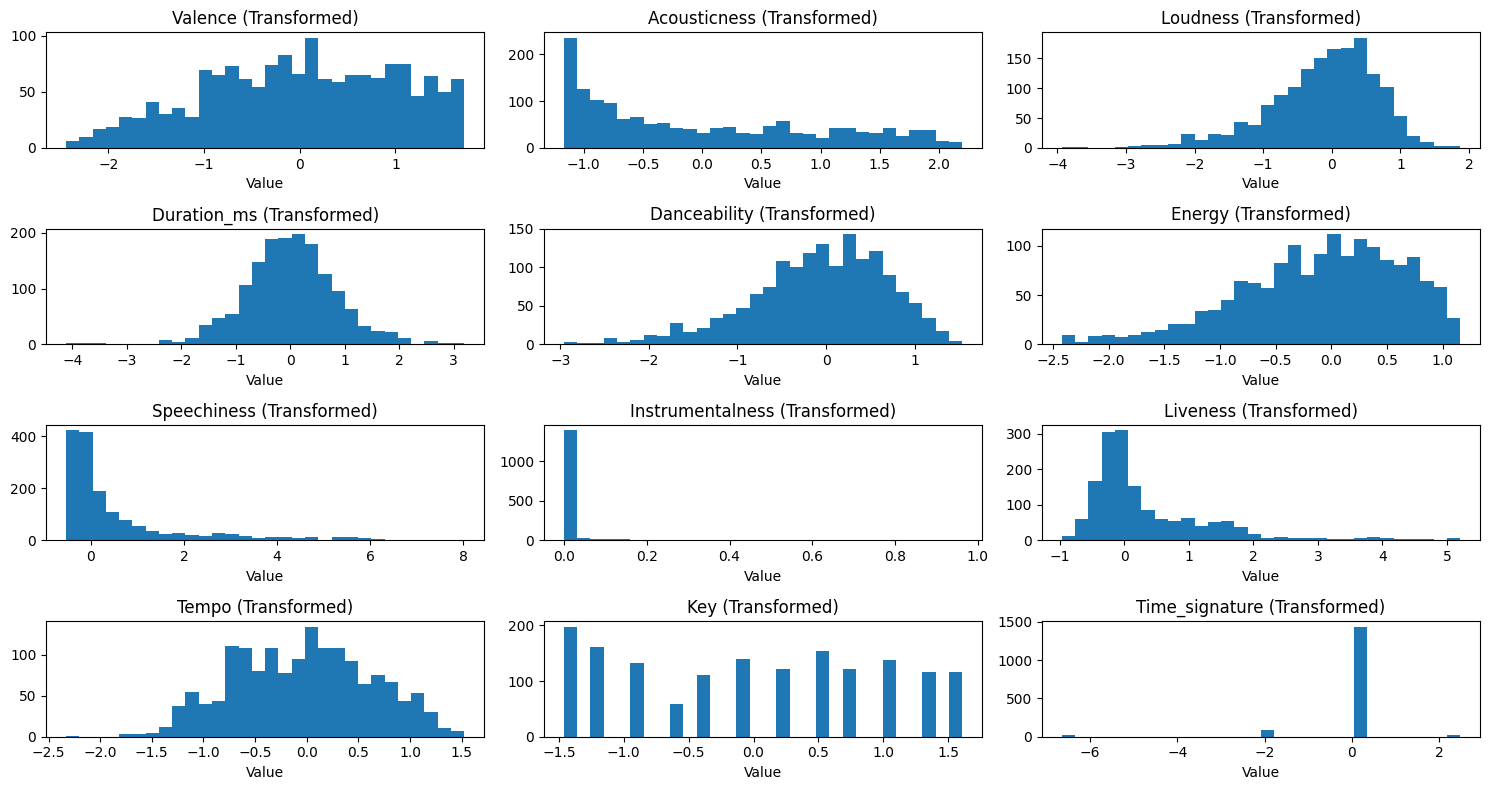

In [28]:
fig, axes = plt.subplots(4, 3, figsize=(15, 8))
axes[0, 0].hist(df_transformed['no_outliers__valence'], bins=30)
axes[0, 0].set_title('Valence (Transformed)')
axes[0, 0].set_xlabel('Value')

axes[0, 1].hist(df_transformed['no_outliers__acousticness'], bins=30)
axes[0, 1].set_title('Acousticness (Transformed)')
axes[0, 1].set_xlabel('Value')

axes[0, 2].hist(df_transformed['outliers_neg__loudness'], bins=30)
axes[0, 2].set_title('Loudness (Transformed)')
axes[0, 2].set_xlabel('Value')

axes[1, 0].hist(df_transformed['outliers_pos__duration_ms'], bins=30)
axes[1, 0].set_title('Duration_ms (Transformed)')
axes[1, 0].set_xlabel('Value')

axes[1, 1].hist(df_transformed['outliers_pos__danceability'], bins=30)
axes[1, 1].set_title('Danceability (Transformed)')
axes[1, 1].set_xlabel('Value')

axes[1, 2].hist(df_transformed['outliers_pos__energy'], bins=30)
axes[1, 2].set_title('Energy (Transformed)')
axes[1, 2].set_xlabel('Value')

axes[2, 0].hist(df_transformed['outliers_pos__speechiness'], bins=30)
axes[2, 0].set_title('Speechiness (Transformed)')
axes[2, 0].set_xlabel('Value')

axes[2, 1].hist(df_transformed['remainder__instrumentalness'], bins=30)
axes[2, 1].set_title('Instrumentalness (Transformed)')
axes[2, 1].set_xlabel('Value')

axes[2, 2].hist(df_transformed['outliers_pos__liveness'], bins=30)
axes[2, 2].set_title('Liveness (Transformed)')
axes[2, 2].set_xlabel('Value')

axes[3, 0].hist(df_transformed['outliers_pos__tempo'], bins=30)
axes[3, 0].set_title('Tempo (Transformed)')
axes[3, 0].set_xlabel('Value')

axes[3, 1].hist(df_transformed['key_time_signature__key'], bins=30)
axes[3, 1].set_title('Key (Transformed)')
axes[3, 1].set_xlabel('Value')

axes[3, 2].hist(df_transformed['key_time_signature__time_signature'], bins=30)
axes[3, 2].set_title('Time_signature (Transformed)')
axes[3, 2].set_xlabel('Value')
plt.tight_layout()
plt.show()

Now the data looks suitable for predictions.

## 2. Fit classifiers

In [29]:
# Cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = {
    "F1-score": "f1",
    "Precision": "precision",
    "Recall": "recall",
    "ROC_AUC": "roc_auc",
    "AP": "average_precision"
}

SVM

In [30]:
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("svm", svm.SVC(probability=True, random_state = 42))])

# Parameter grid
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

svm_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
svm_search.fit(X_train, y_train)

print(f"Best CV F1 = {svm_search.best_score_:.3f}")
print("Best parameters: ", svm_search.best_params_)

# store the best params and best model for later use
SVM_best_params = svm_search.best_params_
SVM_best_model = svm_search.best_estimator_
SVM_best_cv_f1 = svm_search.best_score_

Best CV F1 = 0.723
Best parameters:  {'svm__C': 1, 'svm__gamma': 1, 'svm__kernel': 'rbf'}


Random forest

In [31]:
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("r_forest", RandomForestClassifier(random_state = 42))])
# Parameter grid
param_grid = {
    'r_forest__n_estimators': [10, 20, 30, 40],
    'r_forest__max_depth': [2, 4, 6, 8, 10, 12]
}

r_forest_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
r_forest_search.fit(X_train, y_train) 

print(f"Best CV F1 = {r_forest_search.best_score_:.3f}")
print("Best parameters: ", r_forest_search.best_params_)

# store the best params and best model for later use
r_forest_best_params = r_forest_search.best_params_
r_forest_best_model = r_forest_search.best_estimator_
r_forest_best_cv_f1 = r_forest_search.best_score_

Best CV F1 = 0.714
Best parameters:  {'r_forest__max_depth': 12, 'r_forest__n_estimators': 30}


Gaussian (Normal) Naive Bayes

In [32]:
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("naive_bayes", GaussianNB())])
# Parameter grid
param_grid = {
    'naive_bayes__var_smoothing': [0.00000001, 0.00001, 0.001, 0.1]
}

NB_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
NB_search.fit(X_train, y_train) 

print(f"Best CV F1 = {NB_search.best_score_:.3f}")
print("Best parameters: ", NB_search.best_params_)

# store the best params and best model for later use
NB_best_params = NB_search.best_params_
NB_best_model = NB_search.best_estimator_
NB_best_cv_f1 = NB_search.best_score_

Best CV F1 = 0.645
Best parameters:  {'naive_bayes__var_smoothing': 1e-08}


Logistic regression

In [33]:
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("logistic_reg", LogisticRegression(random_state = 42))])
# Parameter grid, parameters suggested by Google Gemini
param_grid = {
    'logistic_reg__C': [0.01, 0.1, 1, 10, 100],
    'logistic_reg__penalty': ['l1', 'l2'],
    'logistic_reg__solver': ["liblinear", "saga"]
}

logistic_reg_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
logistic_reg_search.fit(X_train, y_train) 

print(f"Best CV F1 = {logistic_reg_search.best_score_:.3f}")
print("Best parameters: ", logistic_reg_search.best_params_)

# store the best params and best model for later use
logistic_reg_best_params = logistic_reg_search.best_params_
logistic_reg_best_model = logistic_reg_search.best_estimator_
logistic_reg_best_cv_f1 = logistic_reg_search.best_score_

Best CV F1 = 0.629
Best parameters:  {'logistic_reg__C': 100, 'logistic_reg__penalty': 'l1', 'logistic_reg__solver': 'liblinear'}


C:\Users\samue\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\samue\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Gradient Boosting Classifier

In [ ]:
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("grad_boost", GradientBoostingClassifier(random_state = 42))])
# Parameter grid, parameters suggested by Google Gemini
param_grid = {
    'grad_boost__learning_rate': [0.05, 0.1],
    'grad_boost__n_estimators': [100, 400],
    'grad_boost__max_depth': [3, 5],
    'grad_boost__min_samples_split': [2, 5],
    'grad_boost__subsample': [0.8,1.0]
}

grad_boost_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
grad_boost_search.fit(X_train, y_train) 

print(f"Best CV F1 = {grad_boost_search.best_score_:.3f}")
print("Best parameters: ", grad_boost_search.best_params_)

# store the best params and best model for later use
grad_boost_best_params = grad_boost_search.best_params_
grad_boost_best_model = grad_boost_search.best_estimator_
grad_boost_best_cv_f1 = grad_boost_search.best_score_

Comparison of the different classifiers:

In [ ]:
# Copied from the lab-exercise
# Compute CV metrics (mean ± std) for the *best* SVM, random forest and naive bayes models
models = {
    "SVM (best by F1)": SVM_best_model,
    "Random Forest (best by F1)": r_forest_best_model,
    "Gaussian Naive Bayes (best by F1)": NB_best_model,
    "Logistic regression (best by F1)": logistic_reg_best_model,
    "Gradient Boosting (best by F1)": grad_boost_best_model
}

cv_results = {}

for name, model in models.items():
    res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[name] = {m: res[f"test_{m}"] for m in scoring.keys()}

# Print a concise summary
for name, metrics_dict in cv_results.items():
    print("\n" + name)
    for m, vals in metrics_dict.items():
        print(f"  {m:9s}: mean={np.mean(vals):.3f}, std={np.std(vals):.3f}")




SVM (best by F1)
  F1-score : mean=0.723, std=0.016
  Precision: mean=0.626, std=0.019
  Recall   : mean=0.856, std=0.025
  ROC_AUC  : mean=0.729, std=0.026
  AP       : mean=0.676, std=0.034

Random Forest (best by F1)
  F1-score : mean=0.720, std=0.042
  Precision: mean=0.711, std=0.028
  Recall   : mean=0.732, std=0.066
  ROC_AUC  : mean=0.783, std=0.036
  AP       : mean=0.765, std=0.042

Gaussian Naive Bayes (best by F1)
  F1-score : mean=0.645, std=0.040
  Precision: mean=0.588, std=0.035
  Recall   : mean=0.717, std=0.059
  ROC_AUC  : mean=0.653, std=0.049
  AP       : mean=0.618, std=0.051

Logistic regression (best by F1)
  F1-score : mean=0.629, std=0.044
  Precision: mean=0.601, std=0.040
  Recall   : mean=0.661, std=0.064
  ROC_AUC  : mean=0.665, std=0.040
  AP       : mean=0.648, std=0.051

Gradient Boosting (best by F1)
  F1-score : mean=0.699, std=0.022
  Precision: mean=0.700, std=0.025
  Recall   : mean=0.700, std=0.047
  ROC_AUC  : mean=0.777, std=0.018
  AP       : 

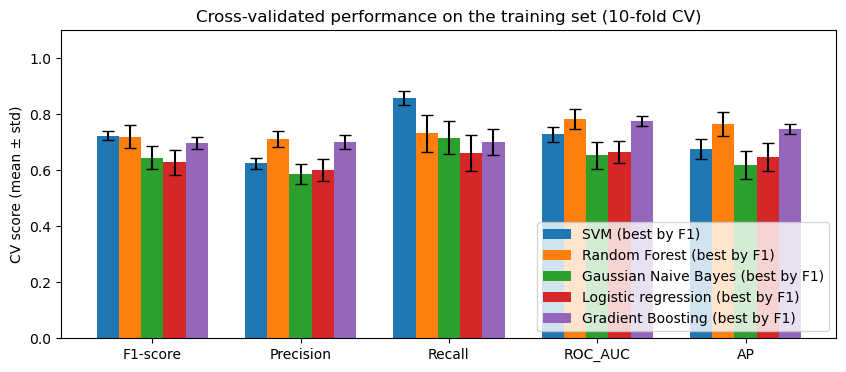

In [ ]:
# Copied from the lab-exercise
# Plot of the mean and std of the metrics of different classifiers
metric_names = list(scoring.keys())
labels = list(cv_results.keys())

# means and stds
means = {lab: [np.mean(cv_results[lab][m]) for m in metric_names] for lab in labels}
stds  = {lab: [np.std(cv_results[lab][m]) for m in metric_names] for lab in labels}

x = np.arange(len(metric_names))
width = 0.15

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width*2, means[labels[0]], width, yerr=stds[labels[0]], capsize=4, label=labels[0])
ax.bar(x - width, means[labels[1]], width, yerr=stds[labels[1]], capsize=4, label=labels[1])
ax.bar(x , means[labels[2]], width, yerr=stds[labels[2]], capsize=4, label=labels[2])
ax.bar(x + width, means[labels[3]], width, yerr=stds[labels[3]], capsize=4, label=labels[3])
ax.bar(x + width*2, means[labels[4]], width, yerr=stds[labels[4]], capsize=4, label=labels[4])

ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=0)
ax.set_ylim(0, 1.1)
ax.set_ylabel("CV score (mean ± std)")
ax.set_title("Cross-validated performance on the training set (10-fold CV)")
ax.legend(loc="lower right")
plt.show()


ROC curve

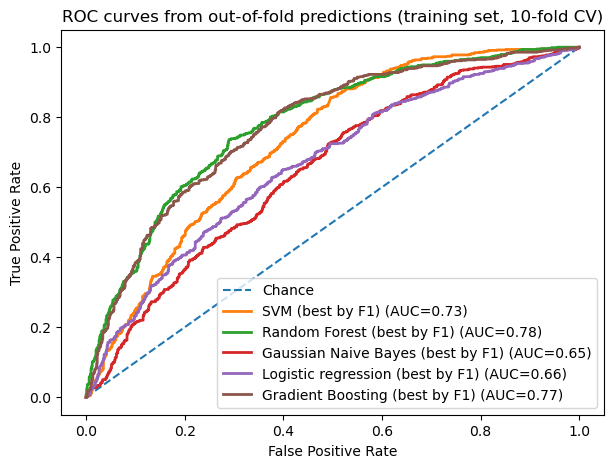

In [ ]:
# Copied from the lab-exercise
# Out-of-fold ROC curves for the two best models (training set only)
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

for name, model in models.items():
    # Out-of-fold probability for class 1 (each point predicted by a model that did not train on it)
    oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

    fpr, tpr, _ = roc_curve(y_train, oof_proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves from out-of-fold predictions (training set, 10-fold CV)")
plt.legend(loc="lower right")
plt.show()


Precision-Recall curve

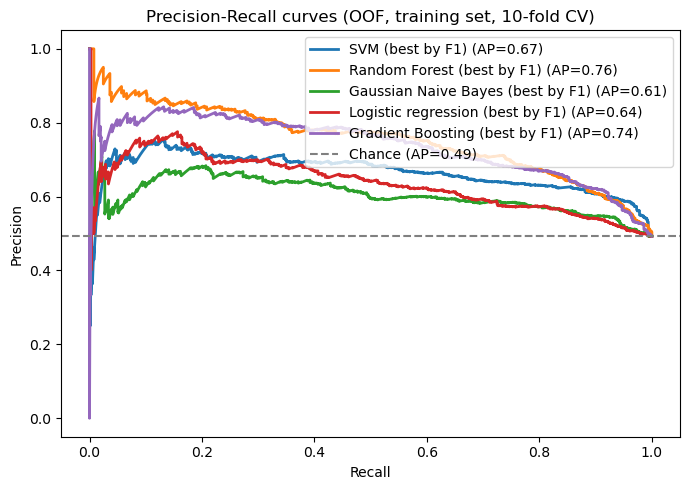

In [ ]:
# PR curves — out-of-fold predictions (training set, all models)
plt.figure(figsize=(7, 5))

for name, model in models.items():
    oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    prec, rec, _ = precision_recall_curve(y_train, oof_proba)
    ap = average_precision_score(y_train, oof_proba)
    plt.plot(rec, prec, lw=2, label=f"{name} (AP={ap:.2f})")

baseline = y_train.mean()
plt.axhline(baseline, linestyle="--", color="grey", label=f"Chance (AP={baseline:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (OOF, training set, 10-fold CV)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

When considering all the factors above, we have 3 options from which to choose the model: RandomForestClassifier, SVM and GradientBoostingClassifier. All of these are performing rather similarly.
When we look at F1-score, SVM is better than RandomForestClassifier by very narrow margin. In recall-metric, SVM is also the best. But when it comes to ROC_AUC, precision and average precision, RandomForestClassifier performs the best. GradientBoostingClassifier is not best in any metric, but very close in each metric. As RandomForestClassifier has highest number of best metrics, we select it to be the final model. RandomForestClassifier provides approximately 70% accuracy, recall, precision and F1-score.

If the recall (share of True positives of all positives) would matter more (e.g. detection of diseases), SVM would be more clear choise as it has the highest recall by a large margin.

In [ ]:
best_model = r_forest_best_model
best_name = "Random Forest"
best_cv_f1 = r_forest_best_cv_f1

## 3. Evaluate the general prediction power of RandomForestClassifier

First, evaluate different metrics. Print out the confusion matrix.

In [ ]:
# Copied from the lab-exercise
def evaluate_model(X_eval, y_eval, model):
    # predicted probabilities for class 1
    probabilities = model.predict_proba(X_eval)[:, 1]

    # predicted class labels
    predicted = model.predict(X_eval)

    # confusion matrix
    cm = confusion_matrix(y_eval, predicted)

    # metrics
    acc = accuracy_score(y_eval, predicted)
    prec = precision_score(y_eval, predicted, zero_division=0)
    rec = recall_score(y_eval, predicted, zero_division=0)
    f1 = f1_score(y_eval, predicted, zero_division=0)

    # ROC curve + AUC
    fpr, tpr, _ = roc_curve(y_eval, probabilities)
    auc_val = auc(fpr, tpr)

    # PR curve + average_precision
    prc_precision, prc_recall, _ = precision_recall_curve(y_eval, probabilities)
    prc_ap = average_precision_score(y_eval, probabilities)

    return cm, acc, prec, rec, f1, fpr, tpr, auc_val, prc_precision, prc_recall, prc_ap
# Final evaluation on the held-out test set (used once for reporting)
test_cm, test_accuracy, test_precision, test_recall, test_f1_score, test_fpr, test_tpr, test_auc, test_prc_precision, test_prc_recall, test_prc_ap = evaluate_model(X_test, y_test, best_model)
cm_df = pd.DataFrame(
    test_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Confusion Matrix (Test Set):")
display(cm_df)
print(f"F1-score: {test_f1_score}")
print(f"Accuracy: {test_accuracy}")
print(f"Recall: {test_recall}")
print(f"Precision: {test_precision}")
print(f"Average precision: {test_prc_ap}")

Confusion Matrix (Test Set):


,Predicted 0,Predicted 1
Actual 0,149,50
Actual 1,56,137


F1-score: 0.7210526315789474
Accuracy: 0.7295918367346939
Recall: 0.7098445595854922
Precision: 0.732620320855615
Average precision: 0.7644472064850824


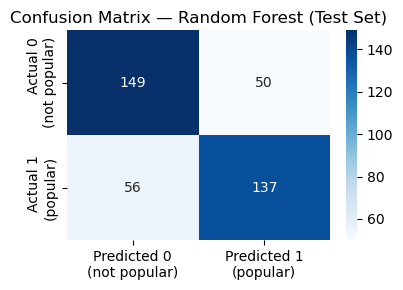

In [ ]:
# Confusion matrix as heatmap
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    test_cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted 0\n(not popular)', 'Predicted 1\n(popular)'],
    yticklabels=['Actual 0\n(not popular)', 'Actual 1\n(popular)'],
    ax=ax
)
ax.set_title(f'Confusion Matrix — {best_name} (Test Set)')
plt.tight_layout()
plt.show()

Plot accuracy, precision, recall and F1-score

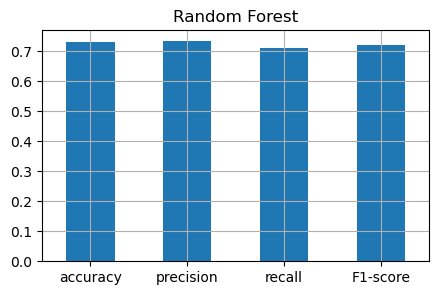

In [ ]:
# Copied from the lab-exercise
metrics = np.array([test_accuracy, test_precision, test_recall, test_f1_score])
index = ['accuracy', 'precision', 'recall', 'F1-score']
df_metrics = pd.DataFrame({best_name: metrics}, index=index)
df_metrics.plot.bar(rot=0, figsize=(5, 3), legend=False, title=f"{best_name}")
plt.grid()
plt.show()

As can be seen, the metrics do not significally drop when evaluating with test set, indicating the model do not overfit to training data. RandomForestClassifier provides over 70% of accuracy, recall, precision and f1-score in the test set.

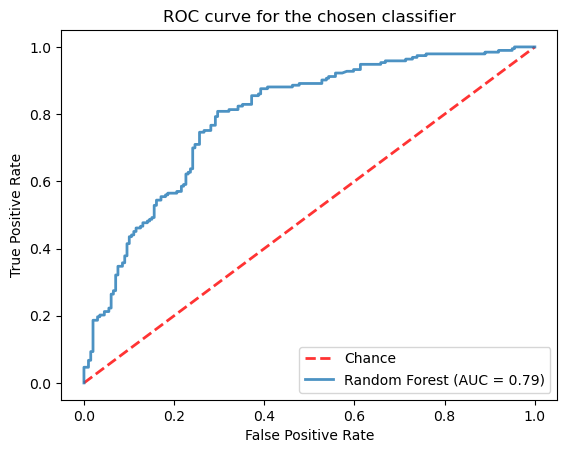

In [ ]:
# Copied from the lab-exercise
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)
plt.plot(test_fpr, test_tpr, lw=2, label=f'{best_name} (AUC = {test_auc:0.2f})', alpha=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for the chosen classifier')
plt.legend(loc="lower right")
plt.show()

Area under curve is way better than with chance.

## 4. Test-Set Evaluation — all models

The table below compares all five models on the held-out test set (used only once for final reporting). The best value per metric is highlighted in green. This allows direct comparison with the CV results above and helps identify any models that overfit (high CV score but lower test score).

In [ ]:
# Test-set evaluation for all models — summary table
all_test_results = []
for name, model in models.items():
    cm_, acc, prec, rec, f1, fpr_, tpr_, auc_val, _, _, ap = evaluate_model(X_test, y_test, model)
    all_test_results.append({
        "Model":      name,
        "Accuracy":   round(acc, 3),
        "Precision":  round(prec, 3),
        "Recall":     round(rec, 3),
        "F1-score":   round(f1, 3),
        "ROC AUC":    round(auc_val, 3),
        "Avg. Prec.": round(ap, 3),
    })

results_df = pd.DataFrame(all_test_results).set_index("Model")
display(results_df.style.highlight_max(axis=0, color='lightgreen').format("{:.3f}"))

,Accuracy,Precision,Recall,F1-score,ROC AUC,Avg. Prec.
Model,,,,,,
SVM (best by F1),0.681,0.625,0.881,0.731,0.759,0.692
Random Forest (best by F1),0.730,0.733,0.710,0.721,0.794,0.764
Gaussian Naive Bayes (best by F1),0.625,0.602,0.705,0.649,0.685,0.655
Logistic regression (best by F1),0.638,0.624,0.663,0.643,0.672,0.652
Gradient Boosting (best by F1),0.717,0.741,0.653,0.694,0.788,0.760


RandomForest still has best values in 3/6 of the metrics when evaluating with test set.

## 5. Feature importance
Let us use a method for model-agnostic global feature importance

In [ ]:
# Use permutation_importance, same way as in example. Let us do same to each model to get the complete picture.
r_forest_feature_importance_result = permutation_importance(
    r_forest_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
SVM_feature_importance_result = permutation_importance(
    SVM_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
logistic_reg_feature_importance_result = permutation_importance(
    logistic_reg_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
grad_boost_feature_importance_result = permutation_importance(
    grad_boost_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
NB_feature_importance_result = permutation_importance(
    NB_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Turn importances to pd.Series
feature_names = X_test.columns
r_forest_importances = pd.Series(r_forest_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
grad_boost_importances = pd.Series(grad_boost_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
NB_importances = pd.Series(NB_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
logistic_reg_importances = pd.Series(logistic_reg_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
SVM_importances = pd.Series(SVM_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)

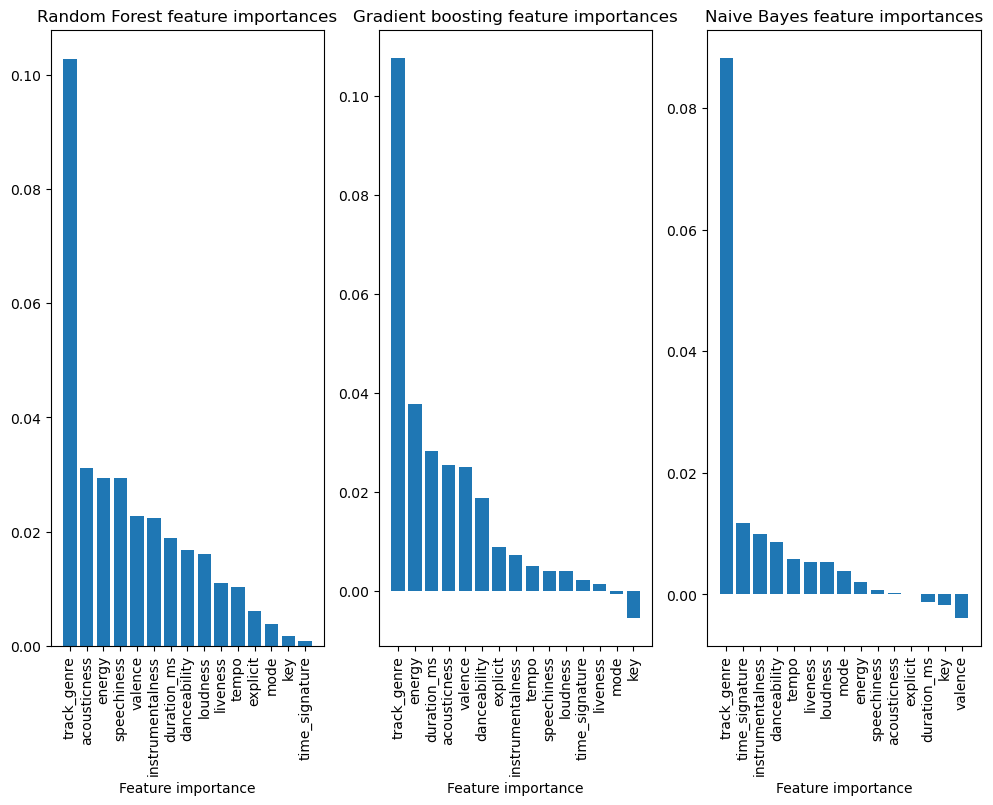

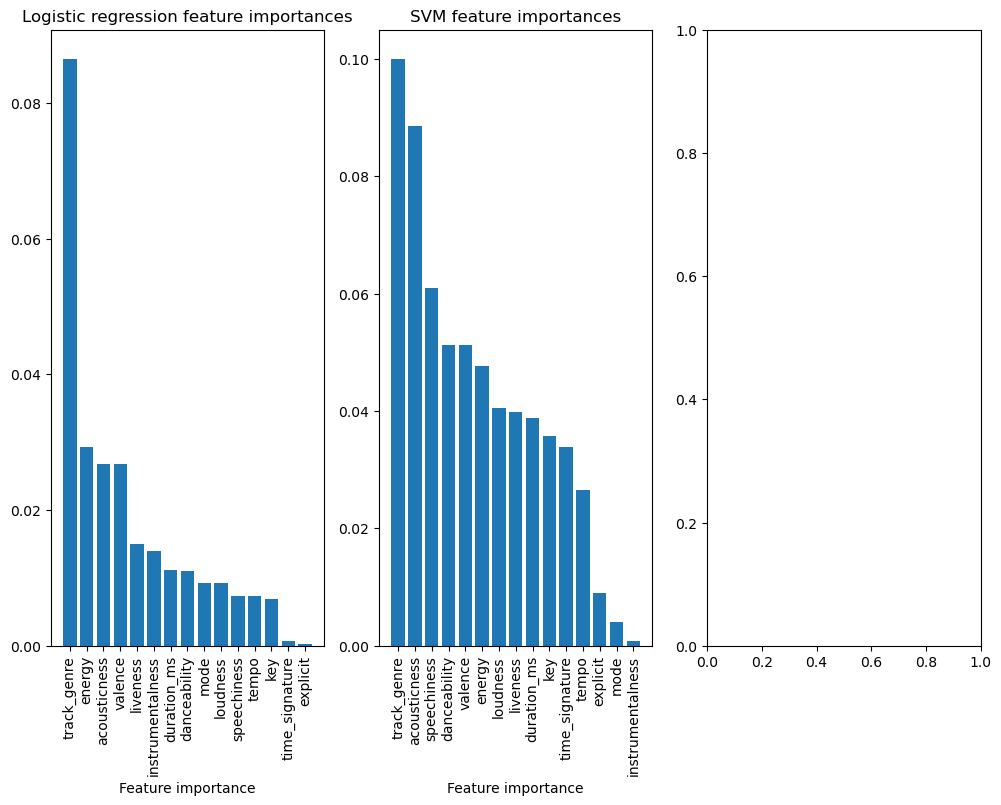

Feature importances of random forest model


track_genre         0.102806
acousticness        0.031122
energy              0.029337
speechiness         0.029337
valence             0.022704
instrumentalness    0.022449
duration_ms         0.018878
danceability        0.016837
loudness            0.016071
liveness            0.010969
tempo               0.010204
explicit            0.006122
mode                0.003827
key                 0.001786
time_signature      0.000765
dtype: float64

In [ ]:
# Plot importances
fig, axes = plt.subplots(1, 3, figsize=(12, 8))
axes[0].bar(r_forest_importances.index, r_forest_importances)
axes[0].set_title('Random Forest feature importances')
axes[0].set_xlabel('Feature importance')
axes[0].tick_params(axis='x', labelrotation=90)
axes[1].bar(grad_boost_importances.index, grad_boost_importances)
axes[1].set_title('Gradient boosting feature importances')
axes[1].set_xlabel('Feature importance')
axes[1].tick_params(axis='x', labelrotation=90)
axes[2].bar(NB_importances.index, NB_importances)
axes[2].set_title('Naive Bayes feature importances')
axes[2].set_xlabel('Feature importance')
axes[2].tick_params(axis='x', labelrotation=90)
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 8))
axes2[0].bar(logistic_reg_importances.index, logistic_reg_importances)
axes2[0].set_title('Logistic regression feature importances')
axes2[0].set_xlabel('Feature importance')
axes2[0].tick_params(axis='x', labelrotation=90)
axes2[1].bar(SVM_importances.index,SVM_importances)
axes2[1].set_title('SVM feature importances')
axes2[1].set_xlabel('Feature importance')
axes2[1].tick_params(axis='x', labelrotation=90)
plt.show()
print("Feature importances of random forest model")
r_forest_importances

### Interpretation of feature importances of all models
As can be seen, track_genre is influencing the most to each of the model performance. Thus, it suggests that it has impact on the prediction of whether or not a song is popular. GradientBoostingClassifier and NaiveBayes have some small negative feature-importances. This indicates that the columns providing negative feature importances are decreasing the model performance.

### Interpretation of the feature importance of RandomForestClassifier
Feature 'track_genre' seems to have the highest impact to the model performance, if it is shuffled (0.10). Also, features 'acousticness', 'energy' and 'speechiness' seem to have higher importance than rest of the features. Shuffling of any of the features do not lead to model performance decrease.

## 6. Conclusions

Best performing classifier is RandomForestClassifier. The decision of continuing with this model was justified by its performance in the training data - it performed best with respect to most of the metrics.

In the test set, RandomForestClassifier leads to the following metrics:
F1-score: 0.72, 
Accuracy: 0.73, 
Recall: 0.71 and
Precision: 0.73.

When looking of the feature importances with permutation importances, column 'track_genre' seems to be most important across the models.